In [688]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

# CSV dosyasindan veri setini oku
pumpkins = pd.read_csv('../data/US-pumpkins.csv')

# ilk 5 satiri goster
pumpkins.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,Mostly High,Origin,Origin District,Item Size,Color,Environment,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,280.0,MARYLAND,NaN,lge,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,280.0,MARYLAND,NaN,lge,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,160.0,DELAWARE,NaN,med,ORANGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,160.0,VIRGINIA,NaN,med,ORANGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,100.0,MARYLAND,NaN,lge,ORANGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [689]:
# Sadece 'bushel' iceren paketleri filtrele
pumpkins = pumpkins[pumpkins['Package'].str.contains('bushel', case=True, regex=True)]

# Kullanılanacak sütunları belirle
new_columns = ['Package', 'Variety', 'City Name', 'Month', 'Low Price', 'High Price', 'Date']
# Gereksiz sütunları kaldır
pumpkins = pumpkins.drop([c for c in pumpkins.columns if c not in new_columns], axis=1)

# Ortalama fiyatı hesapla
price = (pumpkins['High Price'] + pumpkins['Low Price']) / 2

# Tarihten ay bilgisini çıkar
month = pd.DatetimeIndex(pumpkins['Date']).month
# Yılın ilk gününden itibaren gün sayısını hesapla
day_of_year = pd.to_datetime(pumpkins['Date']).apply(lambda x : (x-datetime(x.year, 1, 1)).days)

# Temiz veri seti oluştur
new_pumpkins = pd.DataFrame({
    'Month': month,
    'DayOfYear': day_of_year,
    'Variety': pumpkins['Variety'],
    'City': pumpkins['City Name'],
    'Package': pumpkins['Package'],
    'Low Price': pumpkins['Low Price'],
    'High Price': pumpkins['High Price'],
    'Price': price
})

# Paket fiyatlarını güncelle
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1 1/9'), 'Price'] = price/1.1
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1/2'), 'Price'] = price*2

new_pumpkins.head()

C:\Users\TEKKEŞİN\AppData\Local\Temp\ipykernel_31484\3001571074.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  day_of_year = pd.to_datetime(pumpkins['Date']).apply(lambda x : (x-datetime(x.year, 1, 1)).days)


,Month,DayOfYear,Variety,City,Package,Low Price,High Price,Price
70,9,267,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,15.0,15.0,13.636364
71,9,267,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,18.0,18.0,16.363636
72,10,274,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,18.0,18.0,16.363636
73,10,274,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,17.0,17.0,15.454545
74,10,281,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,15.0,15.0,13.636364


<Axes: xlabel='Month', ylabel='Price'>

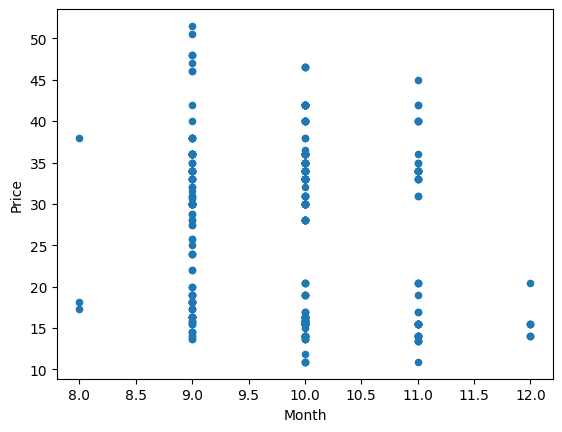

In [690]:
# Ay ve fiyat arasındaki scatter plot
new_pumpkins.plot.scatter('Month', 'Price')

<Axes: xlabel='DayOfYear', ylabel='Price'>

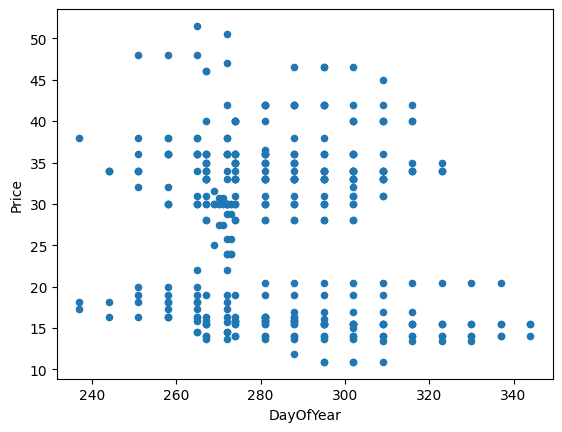

In [691]:
# Yılın gün sayısı ve fiyat arasındaki scatter plot
new_pumpkins.plot.scatter('DayOfYear', 'Price')

In [692]:
# Korelasyon katsayılarını hesapla ve yazdır
print(new_pumpkins['Month'].corr(new_pumpkins['Price']))
print(new_pumpkins['DayOfYear'].corr(new_pumpkins['Price']))

-0.14878293554077535
-0.16673322492745407


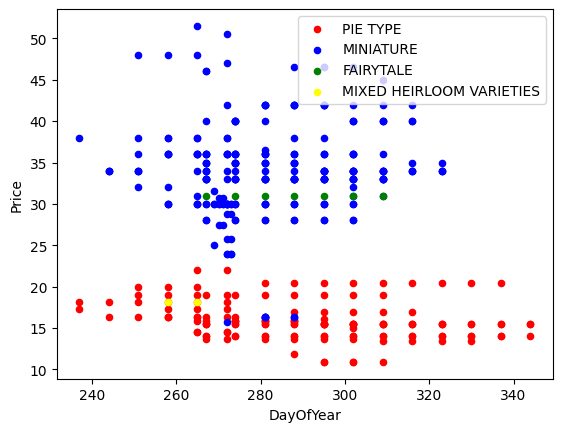

In [693]:
# Grafik ekseni ve renk paleti başlat
ax = None
colors = ['red', 'blue', 'green', 'yellow']

# Her balkabağı çeşidi için ayrı renkli scatter plot oluştur
for i,var in enumerate(new_pumpkins['Variety'].unique()):
    # Her çeşidi filtrele ve farklı renkte plot et
    ax = new_pumpkins[new_pumpkins['Variety'] == var].plot.scatter('DayOfYear', 'Price', ax=ax, c=colors[i], label=var)

<Axes: title={'center': 'Average Price by Month'}, xlabel='Variety', ylabel='Average Price'>

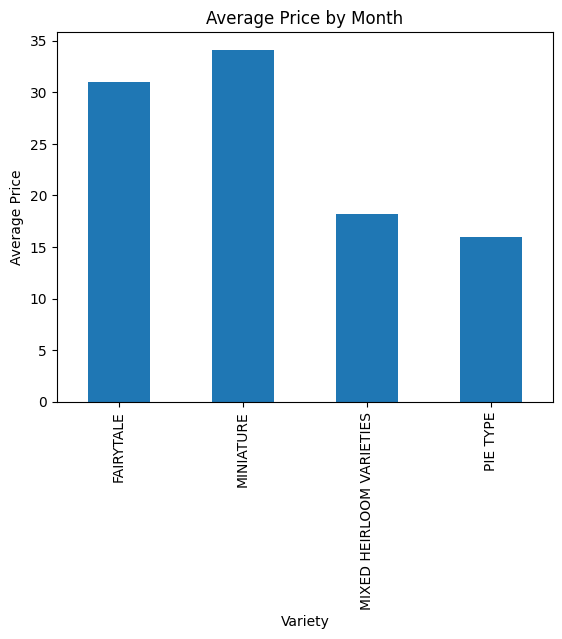

In [694]:
# Çeşitlere göre ortalama fiyatları hesapla ve bar grafiği oluştur
new_pumpkins.groupby('Variety')['Price'].mean().plot(kind='bar', title='Average Price by Month', ylabel='Average Price', xlabel='Variety')

<Axes: xlabel='DayOfYear', ylabel='Price'>

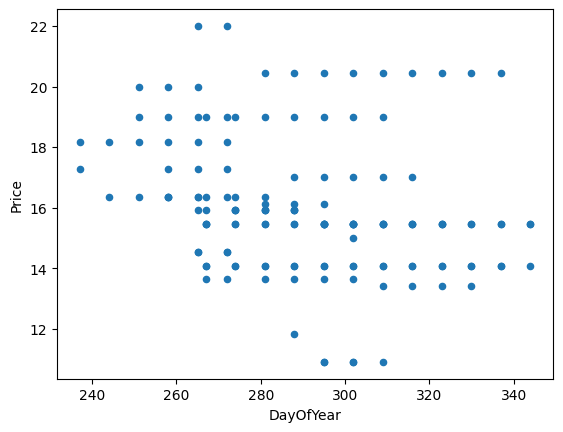

In [695]:
# Sadece 'PIE TYPE' çeşidindeki balkabaklarını filtrele ve scatter plot oluştur
pie_pumpkins = new_pumpkins[new_pumpkins['Variety'] == 'PIE TYPE']
pie_pumpkins.plot.scatter('DayOfYear', 'Price')

In [696]:
# PIE TYPE çeşidi için korelasyon katsayılarını hesapla ve yazdır
print(pie_pumpkins['Month'].corr(pie_pumpkins['Price']))

print(pie_pumpkins['DayOfYear'].corr(pie_pumpkins['Price']))

-0.23841413206125714
-0.2669192282197318


In [697]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [698]:
# Özellik matrisini oluştur (2D array formatında)
X = pie_pumpkins['DayOfYear'].to_numpy().reshape(-1, 1)
# Hedef değişkeni (fiyat) oluştur
y = pie_pumpkins['Price']

X.shape

(144, 1)

In [699]:
# Veriyi eğitim ve test setlerine böl (80% eğitim, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [700]:
# Lineer regresyon modelini oluştur ve eğit
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

LinearRegression()

In [701]:
# Test seti üzerinde tahmin yap
pred = lin_reg.predict(X_test)

pred

array([16.21096253, 16.73652536, 16.08833121, 15.35254325, 15.96569988,
       16.73652536, 16.21096253, 16.36863138, 16.61389403, 15.84306855,
       15.84306855, 15.72043723, 16.21096253, 15.5978059 , 16.45622519,
       15.72043723, 15.5978059 , 16.08833121, 15.72043723, 16.36863138,
       16.85915669, 16.21096253, 15.22991192, 16.21096253, 15.84306855,
       16.45622519, 16.08833121, 15.84306855, 15.5978059 ])

In [702]:
# Root Mean Squared Error (RMSE) hesapla
rmse = np.sqrt(mean_squared_error(y_test, pred))

# MSE ise
# mse = mean_squared_error(y_test, pred)

print(f"Mean error: {rmse:3.3} ({rmse/np.mean(pred)*100:3.3}%)")

Mean error: 2.77 (17.2%)


In [703]:
# Model skorunu (R^2) hesapla
score = lin_reg.score(X_train, y_train)
print("Model determation: ", score)

Model determation:  0.04460606335028361


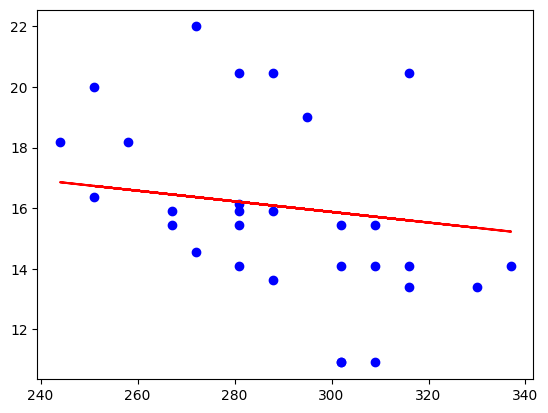

In [704]:
# Gerçek ve tahmin edilen değerleri scatter plot ile göster
plt.scatter(X_test, y_test, color='blue', label='Actual')

plt.plot(X_test, pred, color='red', label='Predicted')

In [705]:
# Doğrusal regresyon denklemini yazdır
print(f"y = {lin_reg.coef_[0]}x + {lin_reg.intercept_}")

y = -0.017518760953105x + 21.133734359909326


In [706]:
# 256. gün için tahmin yap
lin_reg.predict([[256]])

array([16.64893156])

Mean error: 2.73 (17.0%)


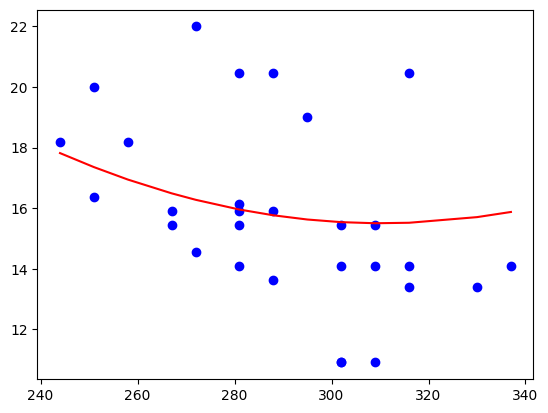

In [707]:
# Polynomial Regression için gerekli kütüphaneleri import et
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 2. derece polynomial özellikler ve linear regresyon modelini oluştur
pipeline = make_pipeline(PolynomialFeatures(2), LinearRegression())

# Pipeline'ı eğit
pipeline.fit(X_train, y_train)

# Polynomial model ile tahmin yap
pred_poly = pipeline.predict(X_test)

# Polynomial model için RMSE hesapla
rmse_poly = np.sqrt(mean_squared_error(y_test, pred_poly))
print(f"Mean error: {rmse_poly:3.3} ({rmse_poly/np.mean(pred_poly)*100:3.3}%)")

# Polynomial model sonuçlarını görselleştir
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(sorted(X_test), pipeline.predict(sorted(X_test)), color='red', label='Predicted')

In [708]:
# Polynomial model skorunu (R^2) hesapla
score = pipeline.score(X_train, y_train)
print("Model determation: ", score)

Model determation:  0.07639977655280128


In [709]:
# Çeşit sütununu dummy değişkenlere çevir
pd.get_dummies(new_pumpkins['Variety'])

,FAIRYTALE,MINIATURE,MIXED HEIRLOOM VARIETIES,PIE TYPE
70,False,False,False,True
71,False,False,False,True
72,False,False,False,True
73,False,False,False,True
74,False,False,False,True
...,...,...,...,...
1738,False,True,False,False
1739,False,True,False,False
1740,False,True,False,False
1741,False,True,False,False


In [710]:
# Kategorik değişkenleri sayısal formata dönüştürme
#X = pd.get_dummies(new_pumpkins['Variety'])

# Çoklu özellik matrisi oluşturma
X = pd.get_dummies(new_pumpkins['Variety'], prefix='Variety', drop_first=True) \
    .join(new_pumpkins['Month']) \
    .join(pd.get_dummies(new_pumpkins['City'], prefix='City', drop_first=True)) \
    .join(pd.get_dummies(new_pumpkins['Package'], prefix='Package', drop_first=True))

# Hedef değişkeni (fiyat) oluştur
y = new_pumpkins['Price']

In [711]:
# Çoklu özellik seti ile verileri eğitim ve test setlerine böl
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Çoklu özellik linear regression modeli
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Çoklu özellik modeli ile tahmin
pred = lin_reg.predict(X_test)

# Çoklu özellik modeli RMSE
rmse = np.sqrt(mean_squared_error(y_test, pred))
print(f"Mean error: {rmse:3.3} ({rmse/np.mean(pred)*100:3.3}%)")

# Çoklu özellik modeli skoru
score = lin_reg.score(X_train, y_train)
print("Model determation: ", score)

Mean error: 2.84 (10.5%)
Model determation:  0.9401401953107826


In [712]:
# Çoklu özellik seti ile verileri eğitim ve test setlerine böl
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Çoklu özellik polynomial pipeline
pipeline = make_pipeline(PolynomialFeatures(2), LinearRegression())
pipeline.fit(X_train, y_train)

# Çoklu özellik polynomial tahmin yap
pred_poly = pipeline.predict(X_test)

# Çoklu özellik polynomial RMSE hesapla
rmse_poly = np.sqrt(mean_squared_error(y_test, pred_poly))
print(f"Mean error: {rmse_poly:3.3} ({rmse_poly/np.mean(pred_poly)*100:3.3}%)")

#Çoklu özellik polynomial skoru
score = pipeline.score(X_train, y_train)
print("Model determation: ", score)

Mean error: 2.23 (8.28%)
Model determation:  0.9653029999448537
